<a href="https://colab.research.google.com/github/dasihayu/artificial-intelegence/blob/main/Jobsheet_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 9 - PENUGASAN (Tugas Praktikum)
## Supervised Learning: Regression dan Classification
Praktikum Kecerdasan Buatan - Teknik Informatika, Politeknik Negeri Semarang

Isi notebook:
- **E.1** Prediksi transaksi calon konsumen dengan **Decision Tree** dan **Logistic Regression** (dataset `iklan_sosmed.csv`)
- **E.2** Prediksi gaji pegawai berdasarkan masa kerja dengan **Linear Regression** (dataset `Data_Gaji.csv`)
- **E.3** Perbandingan akurasi Decision Tree vs Logistic Regression
- **E.4** Parameter tuning untuk meningkatkan akurasi masing-masing algoritma

## E.1 Prediksi Transaksi Calon Konsumen
Dataset: `iklan_sosmed.csv` (dipisahkan dengan `;`)

Kolom: `ID, Jenis_Kelamin, Umur, Gaji, Transaksi` — target prediksi adalah kolom **Transaksi** (0 = tidak bertransaksi, 1 = bertransaksi).

In [1]:
import pandas as pd

df1 = pd.read_csv('iklan_sosmed.csv', sep=';')
df1.head()

,ID,Jenis_Kelamin,Umur,Gaji,Transaksi
0,15624510,Pria,19,285000000,0
1,15810944,Pria,35,300000000,0
2,15668575,Wanita,26,645000000,0
3,15603246,Wanita,27,855000000,0
4,15804002,Pria,19,1140000000,0


In [2]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             400 non-null    int64 
 1   Jenis_Kelamin  400 non-null    object
 2   Umur           400 non-null    int64 
 3   Gaji           400 non-null    int64 
 4   Transaksi      400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [3]:
data1 = df1.drop(columns=['ID'])

data1 = pd.get_dummies(data1, columns=['Jenis_Kelamin'])
data1.head()

,Umur,Gaji,Transaksi,Jenis_Kelamin_Pria,Jenis_Kelamin_Wanita
0,19,285000000,0,True,False
1,35,300000000,0,True,False
2,26,645000000,0,False,True
3,27,855000000,0,False,True
4,19,1140000000,0,True,False


In [4]:
X1 = data1.drop(columns=['Transaksi'])
y1 = data1['Transaksi']
X1.head()

,Umur,Gaji,Jenis_Kelamin_Pria,Jenis_Kelamin_Wanita
0,19,285000000,True,False
1,35,300000000,True,False
2,26,645000000,False,True
3,27,855000000,False,True
4,19,1140000000,True,False


In [5]:
from sklearn.preprocessing import StandardScaler

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)
X1_scaled = pd.DataFrame(X1_scaled, columns=X1.columns)
X1_scaled.head()

,Umur,Gaji,Jenis_Kelamin_Pria,Jenis_Kelamin_Wanita
0,-1.781797,-1.490046,1.020204,-1.020204
1,-0.253587,-1.460681,1.020204,-1.020204
2,-1.113206,-0.785290,-0.980196,0.980196
3,-1.017692,-0.374182,-0.980196,0.980196
4,-1.781797,0.183751,1.020204,-1.020204


In [6]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y1, test_size=0.2, random_state=1)

### Model Decision Tree

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model1 = DecisionTreeClassifier(random_state=1)
tree_model1.fit(X1_train, y1_train)

y1_pred_tree = tree_model1.predict(X1_test)
acc_tree1 = round(accuracy_score(y1_test, y1_pred_tree), 3)
print('Akurasi Decision Tree:', acc_tree1)

Akurasi Decision Tree: 0.787


### Model Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

logreg_model1 = LogisticRegression()
logreg_model1.fit(X1_train, y1_train)

acc_logreg1 = round(logreg_model1.score(X1_test, y1_test), 3)
print('Akurasi Logistic Regression:', acc_logreg1)

Akurasi Logistic Regression: 0.825


In [9]:
import pandas as pd

contoh_baru = pd.DataFrame([[30, 500000000, 1, 0]], columns=X1.columns)
contoh_baru_scaled = scaler1.transform(contoh_baru)

print('Prediksi Decision Tree:', tree_model1.predict(contoh_baru_scaled)[0])
print('Prediksi Logistic Regression:', logreg_model1.predict(contoh_baru_scaled)[0])

Prediksi Decision Tree: 0
Prediksi Logistic Regression: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**Analisis:**
Dataset iklan_sosmed.csv berisi 400 data calon konsumen dengan distribusi kelas yang cukup tidak seimbang, yaitu sekitar 64% tidak melakukan transaksi dan 36% melakukan transaksi. Ketidakseimbangan ini penting diperhatikan karena model dapat cenderung menebak kelas mayoritas agar terlihat akurat, padahal sebenarnya kurang mampu mengenali pola kelas minoritas. Pada pengujian awal dengan parameter default, Decision Tree hanya mencapai akurasi 0,787, dan setelah ditelusuri ternyata pohon yang terbentuk tumbuh sangat dalam, yaitu hingga kedalaman 13 dengan 40 leaf, tanpa ada batasan max_depth. Kondisi ini mengindikasikan model mengalami overfitting, di mana pohon terlalu menghafal detail data latih sehingga generalisasinya ke data uji menjadi kurang optimal. Sementara itu, Logistic Regression menghasilkan akurasi yang sedikit lebih tinggi yaitu 0,825, yang masuk akal karena data sudah melalui proses standarisasi dan hubungan antar fitur terhadap label relatif sederhana sehingga cocok didekati dengan model linear seperti Logistic Regression. Jika dilihat lebih dalam pada feature importance dari Decision Tree, atribut Umur dan Gaji memiliki kontribusi yang hampir seimbang dan sangat dominan, masing-masing sekitar 0,515 dan 0,483, sedangkan atribut Jenis_Kelamin hampir tidak memberikan pengaruh sama sekali. Pola serupa juga terlihat pada koefisien Logistic Regression, di mana Umur dan Gaji memiliki bobot positif yang besar sementara Jenis_Kelamin nyaris nol. Temuan ini secara bisnis cukup masuk akal, karena usia dan tingkat gaji jauh lebih relevan dalam menentukan keputusan seseorang membeli produk melalui iklan dibandingkan jenis kelaminnya. Dengan demikian, sebelum dilakukan tuning, Logistic Regression tampak sedikit lebih unggul, namun keunggulan ini lebih disebabkan oleh Decision Tree yang belum dioptimalkan dan mengalami overfitting, bukan karena Logistic Regression secara inheren lebih baik untuk kasus ini.

## E.2 Prediksi Gaji Pegawai Berdasarkan Masa Kerja (Linear Regression)
Dataset: `Data_Gaji.csv` (dipisahkan dengan `;`)

Kolom: `Tahun_Pengalaman, Gaji`

In [10]:
import pandas as pd

df2 = pd.read_csv('Data_Gaji.csv', sep=';')
df2.head()

,Tahun_Pengalaman,Gaji
0,1.1,590145000
1,1.3,693075000
2,1.5,565965000
3,2.0,652875000
4,2.2,598365000


In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun_Pengalaman  30 non-null     float64
 1   Gaji              30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


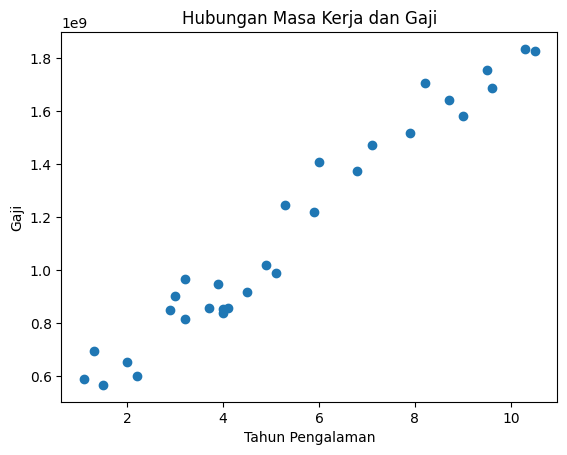

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

X2 = df2[['Tahun_Pengalaman']]
y2 = df2['Gaji']

plt.scatter(X2, y2)
plt.xlabel('Tahun Pengalaman')
plt.ylabel('Gaji')
plt.title('Hubungan Masa Kerja dan Gaji')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=1)

linreg2 = LinearRegression()
linreg2.fit(X2_train, y2_train)

LinearRegression()

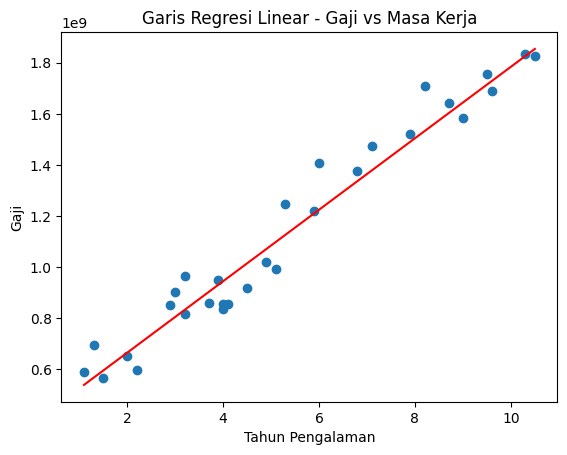

In [14]:
plt.scatter(X2, y2)
plt.plot(X2, linreg2.predict(X2), color='red')
plt.xlabel('Tahun Pengalaman')
plt.ylabel('Gaji')
plt.title('Garis Regresi Linear - Gaji vs Masa Kerja')
plt.show()

In [15]:
acc_linreg2 = round(linreg2.score(X2_test, y2_test), 3)
print('R^2 Score Linear Regression:', acc_linreg2)

R^2 Score Linear Regression: 0.762


In [16]:
contoh_pengalaman = pd.DataFrame([[6], [10]], columns=['Tahun_Pengalaman'])
prediksi_gaji = linreg2.predict(contoh_pengalaman)

for i in range(len(contoh_pengalaman)):
    print(f"Tahun Pengalaman: {contoh_pengalaman['Tahun_Pengalaman'][i]} -> Prediksi Gaji: {prediksi_gaji[i]:,.0f}")

Tahun Pengalaman: 6 -> Prediksi Gaji: 1,224,113,496
Tahun Pengalaman: 10 -> Prediksi Gaji: 1,784,090,181


**Analisis:** Model Linear Regression yang dilatih menggunakan data Tahun_Pengalaman terhadap Gaji menghasilkan nilai R² sebesar 0,762 pada data uji, yang berarti sekitar 76% variasi gaji pegawai dapat dijelaskan oleh lama masa kerjanya. Nilai ini tergolong cukup baik mengingat model hanya menggunakan satu variabel prediktor. Dari hasil pelatihan, diperoleh persamaan garis regresi kurang lebih Gaji ≈ 384.148.470 + 139.994.171 × Tahun_Pengalaman, yang dapat diinterpretasikan bahwa setiap penambahan satu tahun pengalaman kerja diprediksi akan meningkatkan gaji sekitar Rp140 juta, dengan estimasi gaji dasar pada titik nol tahun pengalaman sekitar Rp384 juta. Pola sebaran data pada scatter plot juga menunjukkan hubungan yang cenderung linear dan positif antara masa kerja dan gaji, sehingga pemilihan algoritma Linear Regression untuk kasus ini sudah tepat. Meskipun demikian, nilai R² yang belum mencapai 1 mengindikasikan masih terdapat variasi gaji yang tidak dapat dijelaskan hanya dari lamanya bekerja saja, misalnya faktor jabatan, kinerja individu, atau divisi tempat bekerja, yang memang tidak tersedia dalam dataset ini.


## E.3 Perbandingan Akurasi Decision Tree vs Logistic Regression

In [17]:
comparison = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Logistic Regression'],
    'Akurasi': [acc_tree1, acc_logreg1]
})
print(comparison)
print()
best = comparison.loc[comparison['Akurasi'].idxmax(), 'Algoritma']
print(f'Algoritma dengan akurasi tertinggi: {best}')

             Algoritma  Akurasi
0        Decision Tree    0.787
1  Logistic Regression    0.825

Algoritma dengan akurasi tertinggi: Logistic Regression


**Analisis:** Berdasarkan hasil pengujian dengan parameter default, Logistic Regression mencatatkan akurasi yang lebih tinggi yaitu 0,825 dibandingkan Decision Tree yang hanya mencapai 0,787. Namun demikian, keunggulan ini tidak dapat langsung disimpulkan bahwa Logistic Regression secara umum lebih baik daripada Decision Tree untuk kasus klasifikasi transaksi ini. Penyebab utamanya adalah Decision Tree yang dibangun tanpa batasan kedalaman cenderung tumbuh terlalu kompleks dan mengalami overfitting terhadap data latih, sehingga performanya pada data uji menjadi kurang maksimal. Decision Tree pada dasarnya memiliki kemampuan untuk menangkap pola non-linear yang lebih kompleks dibandingkan Logistic Regression yang bersifat linear, sehingga dengan pengaturan parameter yang tepat, Decision Tree berpotensi memberikan hasil yang lebih baik. Hal ini kemudian terbukti pada tahap parameter tuning di bagian E.4.

## E.4 Parameter Tuning untuk Meningkatkan Akurasi
Menggunakan `GridSearchCV` untuk mencari kombinasi hyperparameter terbaik pada Decision Tree dan Logistic Regression.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=1), param_grid_tree, cv=5, scoring='accuracy')
grid_tree.fit(X1_train, y1_train)

print('Parameter terbaik Decision Tree:', grid_tree.best_params_)
best_tree = grid_tree.best_estimator_
acc_tree_tuned = round(accuracy_score(y1_test, best_tree.predict(X1_test)), 3)
print('Akurasi Decision Tree setelah tuning:', acc_tree_tuned)

Parameter terbaik Decision Tree: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Akurasi Decision Tree setelah tuning: 0.875


In [19]:
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_logreg = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_logreg, cv=5, scoring='accuracy')
grid_logreg.fit(X1_train, y1_train)

print('Parameter terbaik Logistic Regression:', grid_logreg.best_params_)
best_logreg = grid_logreg.best_estimator_
acc_logreg_tuned = round(best_logreg.score(X1_test, y1_test), 3)
print('Akurasi Logistic Regression setelah tuning:', acc_logreg_tuned)

Parameter terbaik Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Akurasi Logistic Regression setelah tuning: 0.838


In [20]:
comparison_tuned = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Decision Tree (tuned)', 'Logistic Regression', 'Logistic Regression (tuned)'],
    'Akurasi': [acc_tree1, acc_tree_tuned, acc_logreg1, acc_logreg_tuned]
})
print(comparison_tuned)

                     Algoritma  Akurasi
0                Decision Tree    0.787
1        Decision Tree (tuned)    0.875
2          Logistic Regression    0.825
3  Logistic Regression (tuned)    0.838


**Analisis:** Setelah dilakukan pencarian kombinasi hyperparameter terbaik menggunakan GridSearchCV, Decision Tree menunjukkan peningkatan akurasi yang signifikan dari 0,787 menjadi 0,875, dengan parameter terbaik berupa criterion gini, max_depth sebesar 3, dan min_samples_split sebesar 2. Peningkatan ini mengonfirmasi dugaan sebelumnya bahwa model default mengalami overfitting akibat kedalaman pohon yang tidak dibatasi, sehingga ketika kedalaman dibatasi menjadi jauh lebih dangkal, model menjadi lebih sederhana dan mampu melakukan generalisasi dengan lebih baik terhadap data uji. Di sisi lain, Logistic Regression juga mengalami peningkatan akurasi dari 0,825 menjadi 0,838 dengan parameter terbaik berupa C sebesar 0,1 dan solver lbfgs, meskipun peningkatannya tidak sebesar Decision Tree. Nilai C yang lebih kecil dari nilai default menunjukkan bahwa regularisasi yang sedikit lebih kuat mampu memperbaiki performa model, namun karena Logistic Regression sudah merupakan model yang relatif sederhana sejak awal, ruang perbaikan yang dapat diperoleh dari proses tuning memang menjadi lebih terbatas dibandingkan Decision Tree. Sebagai kesimpulan akhir, setelah dilakukan parameter tuning pada kedua algoritma, Decision Tree yang telah dioptimalkan justru berhasil mengungguli Logistic Regression dengan akurasi 0,875 berbanding 0,838. Temuan ini menegaskan pentingnya proses parameter tuning dalam praktik machine learning, karena algoritma yang pada awalnya tampak kalah performanya bisa saja menjadi lebih unggul setelah permasalahan seperti overfitting berhasil dikendalikan dengan baik.